# Assault Time Series Modeling

## Import Packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import itertools
import numpy as np

In [2]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import LinearRegression, LogisticRegression, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, confusion_matrix, classification_report, precision_recall_curve, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import RandomOverSampler

In [3]:
import os
print(os.getcwd())


c:\Data Science\2025 - Summer\Capstone B\Analysis\Modeling


In [4]:
try:
    df = pd.read_csv('../Data/Combined Datasets/combined_all.csv', low_memory=False)
    assault_df = df[df["type"] == "assault"].copy()
    assault_df["admit_datetime"] = pd.to_datetime(assault_df["admit_datetime"], errors="coerce")
    assault_df["date"] = assault_df["admit_datetime"].dt.date
except FileNotFoundError:
    print("Note: ../Data/Combined Datasets/combined_all.csv not found. Using local files if available.")
    assault_df = pd.DataFrame()

# --- Load Heat Related Deaths Data (CSV with fallback) ---
try:
    import os
    for csv_path in [
        'Heat_Related_2021-2024.csv',
        '../Data/Heat_Related_2021-2024.csv',
        '../Data/Heat Related Deaths/Heat_Related_2021-2024.csv',
    ]:
        if os.path.exists(csv_path):
            heat_df = pd.read_csv(csv_path)
            break
    else:
        frames = []
        for xl_path in [
            'Heat Related 2021-2024.xlsx',
            'Heat Related 2024 EOY Coroner-dataset.xlsx',
            'Heat Deaths EOY 2025.xlsx',
        ]:
            if os.path.exists(xl_path):
                frames.append(pd.read_excel(xl_path))
        if frames:
            heat_df = pd.concat(frames, ignore_index=True)
        else:
            raise FileNotFoundError("No heat-related deaths source file found.")

    heat_df.drop_duplicates(subset=['Case #'], inplace=True)
    heat_df['Date of Death'] = pd.to_datetime(heat_df['Date of Death'])
    daily_heat_deaths = heat_df.groupby('Date of Death').size().rename('heat_death_count').reset_index()
    daily_heat_deaths.rename(columns={'Date of Death': 'date'}, inplace=True)
    daily_heat_deaths['date'] = pd.to_datetime(daily_heat_deaths['date']).dt.date
    print(f"Success: Loaded {len(heat_df)} total heat-related death records.")
except Exception as e:
    print(f"Warning: Could not load heat related deaths: {e}")
    daily_heat_deaths = pd.DataFrame(columns=['date', 'heat_death_count'])


In [5]:
if 'df' in locals():
    print(df.dtypes.value_counts())
else:
    print("Combined dataset not loaded.")


## Feature Engineering

In [6]:
# Create daily counts for assaults
if not assault_df.empty:
    daily_assault = assault_df.groupby("date").size().rename("incident_count").reset_index()
else:
    daily_assault = pd.DataFrame(columns=["date", "incident_count"])

# Daily averages for relevant weather features
weather_cols = [
    "temperature_2m_f", "relative_humidity_2m_", "dew_point_2m_f",
    "apparent_temperature_f", "snowfall_inch", "rain_inch",
    "precipitation_inch", "wind_speed_10m_mph", "wet_bulb_temperature_2m_f",
    "uv_index_", "uv_index_clear_sky_"
]

if not assault_df.empty:
    daily_weather = (
        assault_df.groupby("date")[weather_cols]
        .mean()
        .reset_index()
    )
else:
    daily_weather = pd.DataFrame(columns=["date"] + weather_cols)

# Merge to build the time series dataframe
daily_assault_ts = pd.merge(daily_assault, daily_weather, on="date", how="outer")

# Merge with Heat Related Deaths
daily_assault_ts = pd.merge(daily_assault_ts, daily_heat_deaths, on="date", how="outer").fillna(0)

numeric_cols = ["incident_count", "heat_death_count"] + weather_cols
for col in numeric_cols:
    if col in daily_assault_ts.columns:
        daily_assault_ts[col] = pd.to_numeric(daily_assault_ts[col], errors="coerce").fillna(0)

daily_assault_ts["date"] = pd.to_datetime(daily_assault_ts["date"])
daily_assault_ts.set_index("date", inplace=True)
daily_assault_ts.sort_index(inplace=True)


In [7]:
# Heatwave definitions
daily_assault_ts["mod_heatwave"] = (
    (daily_assault_ts["temperature_2m_f"] > 90).rolling(window=3).sum() >= 3
).astype(int)
daily_assault_ts["extreme_heat"] = (daily_assault_ts["temperature_2m_f"] > 100).astype(int)
daily_assault_ts["past_week_heat_days"] = (
    (daily_assault_ts["temperature_2m_f"] > 90).astype(int).rolling(window=7).sum()
)
daily_assault_ts["cumulative_heat_stress"] = (
    (daily_assault_ts["temperature_2m_f"] - 90)
    .clip(lower=0)
    .rolling(window=3)
    .sum()
)


# Lags
daily_assault_ts["lag1"] = daily_assault_ts["incident_count"].shift(1)
daily_assault_ts["lag7"] = daily_assault_ts["incident_count"].shift(7)

# Rolling means
daily_assault_ts["rolling_mean_3"] = daily_assault_ts["incident_count"].rolling(3).mean()
daily_assault_ts["rolling_mean_7"] = daily_assault_ts["incident_count"].rolling(7).mean()

# High UV flag
daily_assault_ts["high_uv_flag"] = (daily_assault_ts["uv_index_"] >= 6).astype(int)

# Temperature buckets
daily_assault_ts["temp_category"] = pd.cut(
    daily_assault_ts["temperature_2m_f"],
    bins=[-np.inf, 60, 75, 90, np.inf],
    labels=["cold", "mild", "warm", "hot"]
)

# Interaction terms
daily_assault_ts["temp_uv_interaction"] = (
    daily_assault_ts["apparent_temperature_f"] * daily_assault_ts["uv_index_clear_sky_"]
)

daily_assault_ts["heat_uv_interaction"] = (
    daily_assault_ts["mod_heatwave"] * daily_assault_ts["uv_index_clear_sky_"]
)


In [8]:
# Add dummies
temp_dummies = pd.get_dummies(daily_assault_ts["temp_category"], prefix="temp", drop_first=True)

# Final exog
exog_assault = pd.concat([
    daily_assault_ts[[
        "apparent_temperature_f", "uv_index_clear_sky_", "mod_heatwave",
        "extreme_heat", "past_week_heat_days", "cumulative_heat_stress",
        "lag1", "lag7", "rolling_mean_3", "rolling_mean_7",
        "high_uv_flag", "temp_uv_interaction", "heat_uv_interaction",
        "heat_death_count"
    ]],
    temp_dummies
], axis=1)



# Final alignment
combined = pd.concat([daily_assault_ts["incident_count"], exog_assault], axis=1).dropna()
aligned_target_assault = combined["incident_count"]
exog_assault = combined.drop(columns=["incident_count"])


In [9]:
print(aligned_target_assault.dtypes)
print(exog_assault.dtypes.value_counts())


int64
float64    10
int64       3
bool        3
Name: count, dtype: int64


In [10]:
print(exog_assault.select_dtypes(include="object").columns)
print(exog_assault.select_dtypes(include="bool").columns)
print(exog_assault.isnull().sum().sort_values(ascending=False).head(10))


Index([], dtype='object')
Index(['temp_mild', 'temp_warm', 'temp_hot'], dtype='object')
apparent_temperature_f    0
uv_index_clear_sky_       0
mod_heatwave              0
extreme_heat              0
past_week_heat_days       0
cumulative_heat_stress    0
lag1                      0
lag7                      0
rolling_mean_3            0
rolling_mean_7            0
dtype: int64


In [11]:
exog_assault[["temp_mild", "temp_warm", "temp_hot"]] = exog_assault[["temp_mild", "temp_warm", "temp_hot"]].astype(float)


## Modeling

### Stationarity Testing

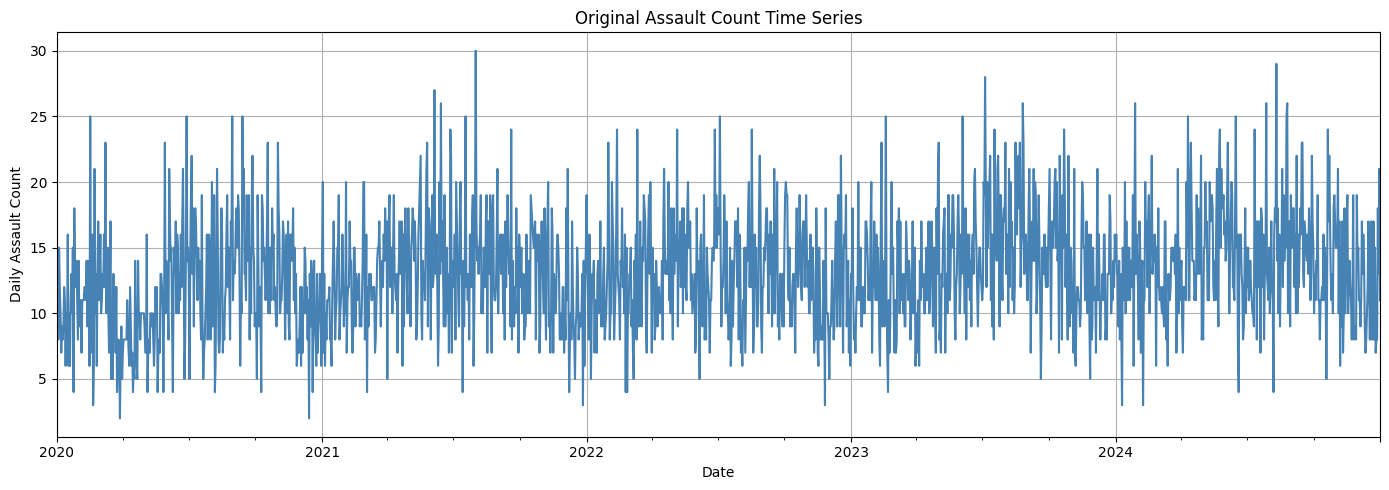

ADF Statistic: -6.4670050044388345
p-value: 1.3971816359349998e-08


In [12]:
# Plot original time series
ic = daily_assault_ts["incident_count"]

if ic.empty or ic.nunique() <= 1:
    print("Skipping plot and ADF test: incident_count is empty or constant (no assault data loaded).")
    print("ACTION REQUIRED: Place combined_all.csv at ../Data/Combined Datasets/ and re-run.")
else:
    ic.plot(
        figsize=(14, 5),
        title="Original Assault Count Time Series",
        color="steelblue",
        linewidth=1.5
    )
    plt.xlabel("Date")
    plt.ylabel("Daily Assault Count")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Run Augmented Dickey-Fuller test for stationarity
    adf_result = adfuller(ic)
    print("ADF Statistic:", adf_result[0])
    print("p-value:", adf_result[1])


Reject the null and continue.

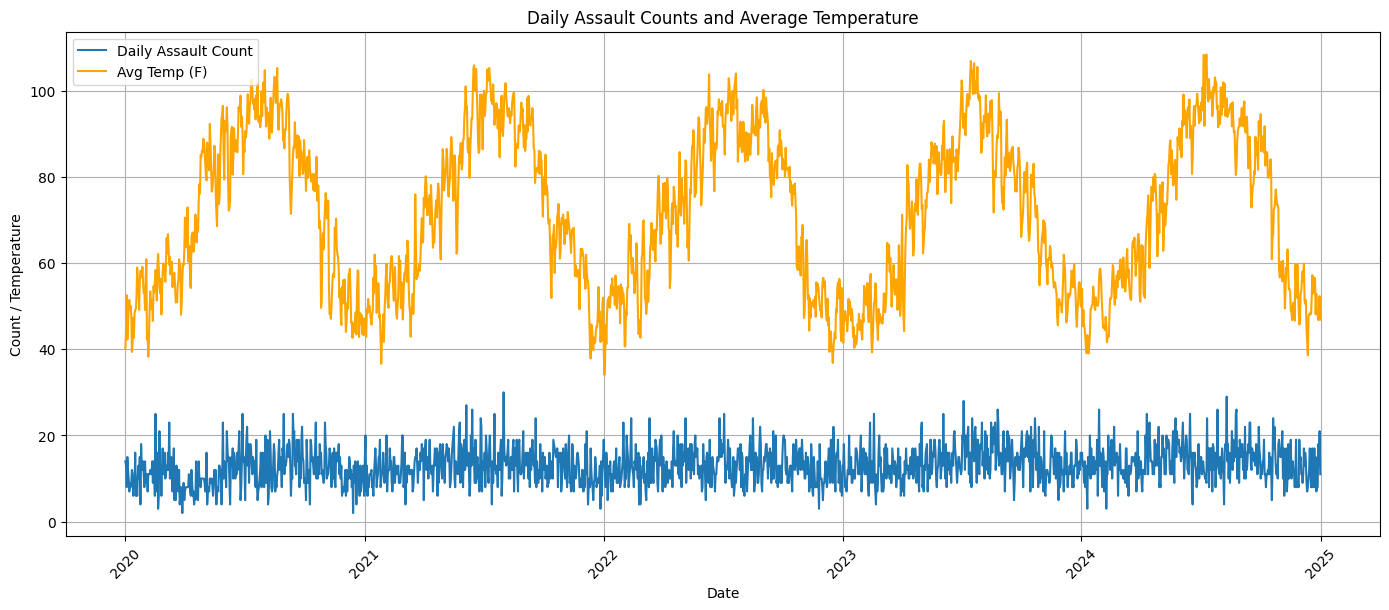

In [13]:
# Plot: Assaults, Heat Deaths, and Temperature
plt.figure(figsize=(14, 7))

sns.lineplot(data=daily_assault_ts, x="date", y="incident_count", label="Daily Assault Count", color="steelblue", alpha=0.8)
sns.lineplot(data=daily_assault_ts, x="date", y="heat_death_count", label="Heat Related Deaths", color="crimson", linewidth=2)
sns.lineplot(data=daily_assault_ts, x="date", y="temperature_2m_f", label="Avg Temp (F)", color="orange", alpha=0.5)

plt.title("Daily Assault Counts, Heat Related Deaths, and Average Temperature")
plt.xlabel("Date")
plt.ylabel("Count / Temperature")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


In [14]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarimax_assault = SARIMAX(
    aligned_target_assault,
    order=(3, 1, 3),
    seasonal_order=(1, 0, 1, 7),
    exog=exog_assault
)
results_assault = sarimax_assault.fit()
print(results_assault.summary())


C:\Users\big_d\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\big_d\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\big_d\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                      
Dep. Variable:                      incident_count   No. Observations:                 1820
Model:             SARIMAX(3, 1, 3)x(1, 0, [1], 7)   Log Likelihood               -4478.342
Date:                             Mon, 30 Jun 2025   AIC                           9006.683
Time:                                     20:08:41   BIC                           9144.334
Sample:                                 01-08-2020   HQIC                          9057.469
                                      - 12-31-2024                                         
Covariance Type:                               opg                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
apparent_temperature_f     0.0270      0.009      3.081      0.002       0.010    

### Computing MAE and RMSE

In [15]:
mae = mean_absolute_error(aligned_target_assault, results_assault.fittedvalues)
rmse = np.sqrt(mean_squared_error(aligned_target_assault, results_assault.fittedvalues))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")


MAE: 2.26, RMSE: 2.96


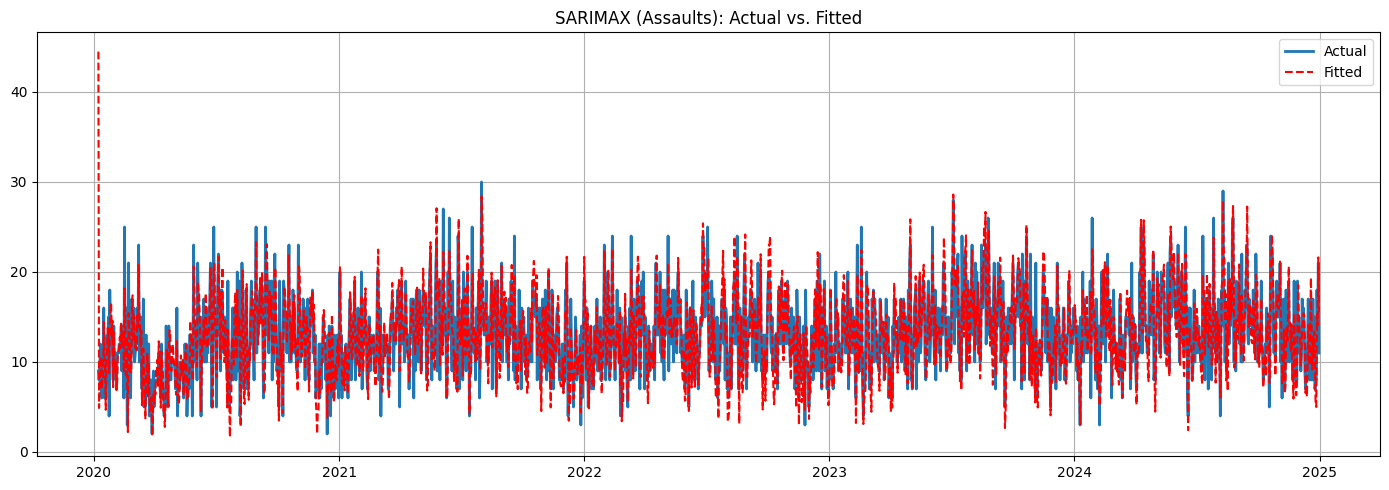

In [16]:
plt.figure(figsize=(14, 5))
plt.plot(aligned_target_assault.index, aligned_target_assault, label="Actual", linewidth=2)
plt.plot(aligned_target_assault.index, results_assault.fittedvalues, label="Fitted", color="red", linestyle="--")
plt.title("SARIMAX (Assaults): Actual vs. Fitted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 14 Day Forecast

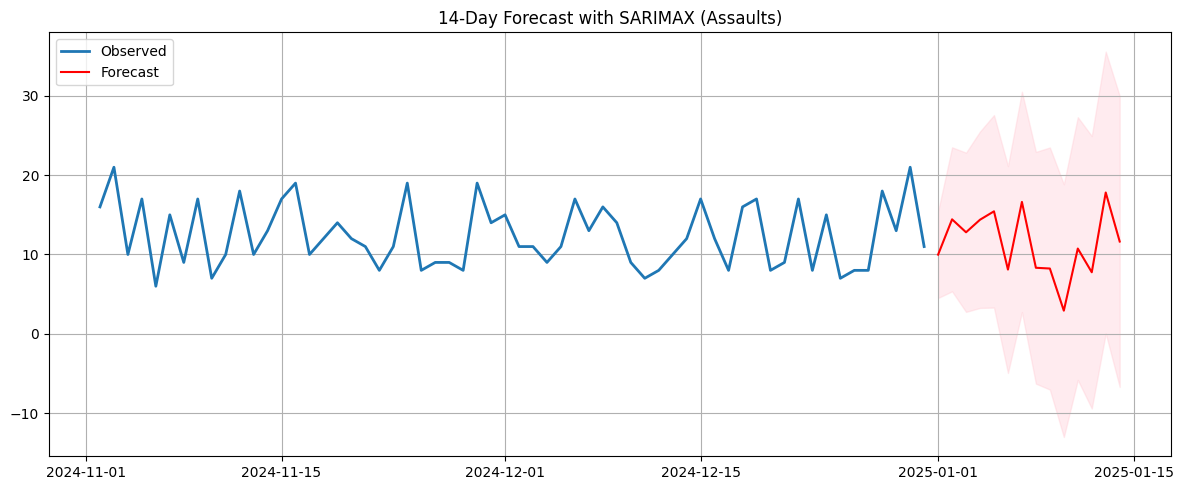

In [17]:
# Generate forecast for 14 days ahead using last exog rows
forecast_steps = 14
forecast = results_assault.get_forecast(steps=forecast_steps, exog=exog_assault.tail(forecast_steps))

forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Plot
plt.figure(figsize=(12, 5))
plt.plot(aligned_target_assault[-60:], label="Observed", linewidth=2)
plt.plot(forecast_mean.index, forecast_mean, label="Forecast", color="red")
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color="pink",
    alpha=0.3
)
plt.title("14-Day Forecast with SARIMAX (Assaults)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Residuals

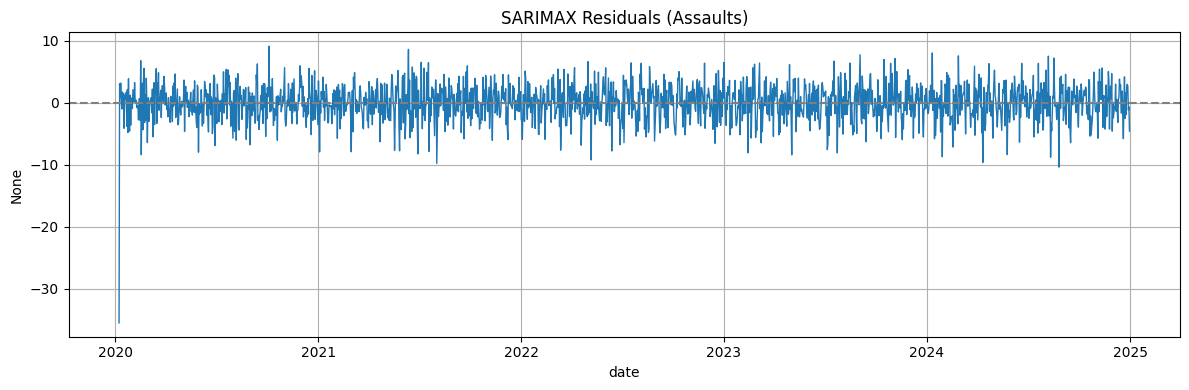

In [18]:
residuals = results_assault.resid

plt.figure(figsize=(12, 4))
sns.lineplot(x=residuals.index, y=residuals, lw=1)
plt.title("SARIMAX Residuals (Assaults)")
plt.axhline(0, color='gray', linestyle='--')
plt.grid(True)
plt.tight_layout()
plt.show()


### Feature Importance

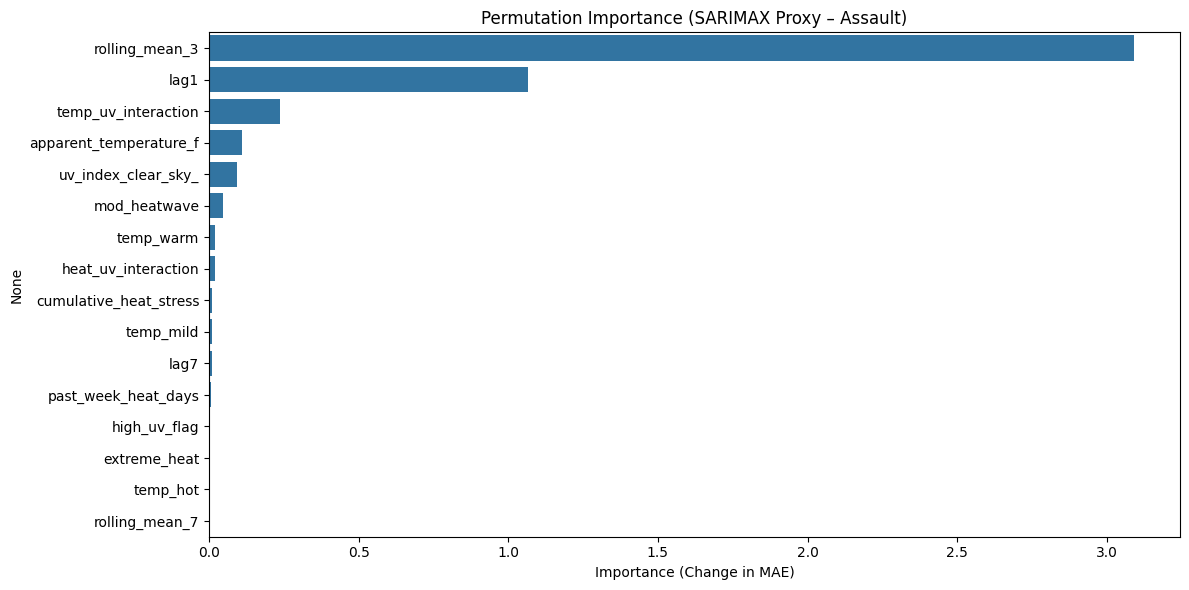

In [19]:
# Linear proxy model
ols_model = LinearRegression()
ols_model.fit(exog_assault, aligned_target_assault)

perm_result = permutation_importance(
    ols_model, exog_assault, aligned_target_assault,
    scoring='neg_mean_absolute_error',
    n_repeats=30,
    random_state=35
)

# Plot
sorted_idx = perm_result.importances_mean.argsort()[::-1]

plt.figure(figsize=(12,6))
sns.barplot(
    x=perm_result.importances_mean[sorted_idx],
    y=exog_assault.columns[sorted_idx]
)
plt.title("Permutation Importance (SARIMAX Proxy – Assault)")
plt.xlabel("Importance (Change in MAE)")
plt.tight_layout()
plt.show()


### Visualizing the Seasonality

#### Daily (Throughout the Week)

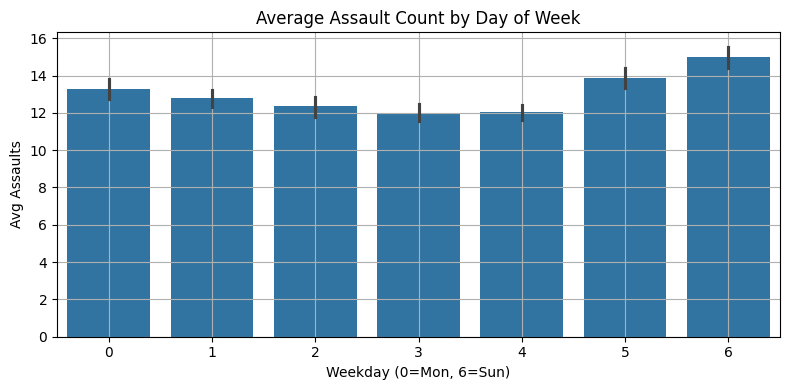

In [20]:
# Add day-of-week column (0=Monday, 6=Sunday)
daily_assault_ts["weekday"] = daily_assault_ts.index.dayofweek

# Plot average assaults by weekday
plt.figure(figsize=(8, 4))
sns.barplot(
    data=daily_assault_ts.reset_index(),
    x="weekday", y="incident_count",
    estimator=np.mean
)
plt.title("Average Assault Count by Day of Week")
plt.xlabel("Weekday (0=Mon, 6=Sun)")
plt.ylabel("Avg Assaults")
plt.grid(True)
plt.tight_layout()
plt.show()


#### Monthly (Throughout the Year)

C:\Users\big_d\AppData\Local\Temp\ipykernel_1316\3984351153.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


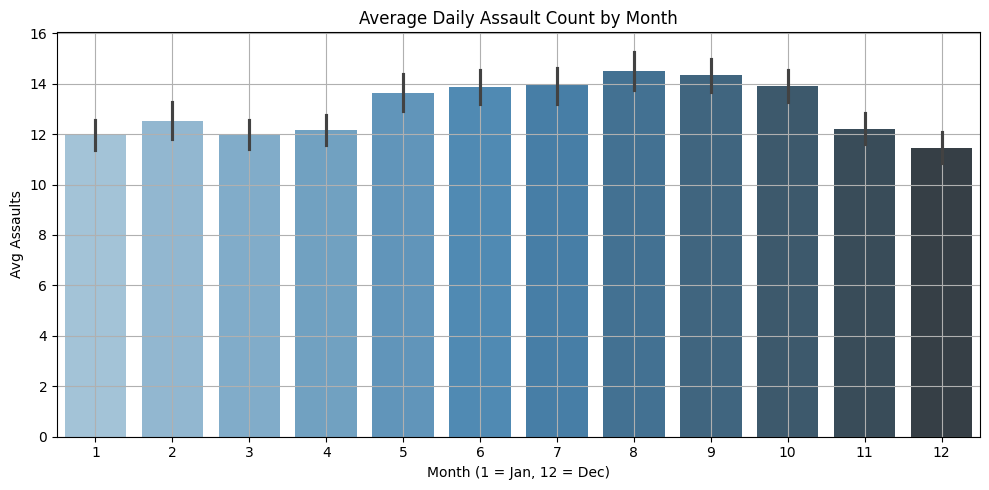

In [21]:
# Create a 'month' column
daily_assault_ts["month"] = daily_assault_ts.index.month
daily_assault_ts["year"] = daily_assault_ts.index.year

# Monthly average across all years
plt.figure(figsize=(10, 5))
sns.barplot(
    data=daily_assault_ts,
    x="month", y="incident_count",
    estimator=np.mean,
    palette="Blues_d"
)
plt.title("Average Daily Assault Count by Month")
plt.xlabel("Month (1 = Jan, 12 = Dec)")
plt.ylabel("Avg Assaults")
plt.grid(True)
plt.tight_layout()
plt.show()


## Enhanced Modeling

### Weekly Enhanced SARIMAX

In [22]:
sarimax_assault = SARIMAX(
    aligned_target_assault,
    order=(3, 1, 3),
    seasonal_order=(1, 0, 1, 7),  # Weekly seasonality
    exog=exog_assault
)
results_assault = sarimax_assault.fit()
print(results_assault.summary())

C:\Users\big_d\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\big_d\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\big_d\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                      
Dep. Variable:                      incident_count   No. Observations:                 1820
Model:             SARIMAX(3, 1, 3)x(1, 0, [1], 7)   Log Likelihood               -4478.342
Date:                             Mon, 30 Jun 2025   AIC                           9006.683
Time:                                     20:08:51   BIC                           9144.334
Sample:                                 01-08-2020   HQIC                          9057.469
                                      - 12-31-2024                                         
Covariance Type:                               opg                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
apparent_temperature_f     0.0270      0.009      3.081      0.002       0.010    

### Monthly Enhanced SARIMAX

In [23]:
monthly_assault_ts = daily_assault_ts.resample("M").agg({
    "incident_count": "sum",
    "apparent_temperature_f": "mean",
    "uv_index_clear_sky_": "mean",
    "mod_heatwave": "sum",  # Cumulative heatwave days
    "high_uv_flag": "sum"
})
monthly_assault_ts["month"] = monthly_assault_ts.index.month
monthly_assault_ts["year"] = monthly_assault_ts.index.year


C:\Users\big_d\AppData\Local\Temp\ipykernel_1316\1347045327.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_assault_ts = daily_assault_ts.resample("M").agg({


In [24]:
# Rolling features (months)
monthly_assault_ts["lag1"] = monthly_assault_ts["incident_count"].shift(1)
monthly_assault_ts["rolling_mean_3"] = monthly_assault_ts["incident_count"].rolling(3).mean()

# Drop NA
monthly_combined = monthly_assault_ts.dropna()
monthly_y = monthly_combined["incident_count"]
monthly_X = monthly_combined.drop(columns=["incident_count", "year", "month"])


In [25]:
monthly_model = SARIMAX(
    monthly_y,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 12),  # Annual seasonality
    exog=monthly_X
)
monthly_results = monthly_model.fit()
print(monthly_results.summary())


                                     SARIMAX Results                                      
Dep. Variable:                     incident_count   No. Observations:                   58
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                -259.431
Date:                            Mon, 30 Jun 2025   AIC                            540.863
Time:                                    20:08:52   BIC                            563.336
Sample:                                03-31-2020   HQIC                           549.597
                                     - 12-31-2024                                         
Covariance Type:                              opg                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
apparent_temperature_f     0.3670      0.757      0.485      0.628      -1.117       1.850

C:\Users\big_d\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Classification Models

Defining Target Variable

In [26]:
# Create binary classification target
combined["high_assault"] = (combined["incident_count"] >= 20).astype(int)
y_class = combined["high_assault"]
X_class = exog_assault.copy()

Train/Test Splitting

In [27]:
# Split into train/test sets
train_size = int(0.85 * len(X_class))
X_train, X_test = X_class[:train_size], X_class[train_size:]
y_train, y_test = y_class[:train_size], y_class[train_size:]

Scaling Unbalanced Data

In [28]:
# Scale ONLY the unbalanced data
scaler_unbalanced = StandardScaler()
X_train_unbal_scaled = scaler_unbalanced.fit_transform(X_train)
X_test_unbal_scaled = scaler_unbalanced.transform(X_test)

Modeling Prior to Oversampling

In [29]:
logreg_orig = LogisticRegression(max_iter=1000)
logreg_orig.fit(X_train_unbal_scaled, y_train)
y_pred_orig = logreg_orig.predict(X_test_unbal_scaled)

print("📊 Logistic Regression BEFORE Oversampling:")
print("Accuracy:", accuracy_score(y_test, y_pred_orig))
print(classification_report(y_test, y_pred_orig))

📊 Logistic Regression BEFORE Oversampling:
Accuracy: 0.9120879120879121
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       245
           1       0.67      0.29      0.40        28

    accuracy                           0.91       273
   macro avg       0.80      0.63      0.68       273
weighted avg       0.90      0.91      0.90       273



Oversampling, Scaling Separately, Then Modeling

In [30]:
# Oversampling
ros = RandomOverSampler(random_state=35)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

In [31]:
# New scaler for resampled data
scaler_resampled = StandardScaler()
X_train_resampled_scaled = scaler_resampled.fit_transform(X_resampled)
X_test_resampled_scaled = scaler_resampled.transform(X_test)

Testing on Oversampled Data

In [32]:
logreg_oversampled = LogisticRegression(max_iter=1000)
logreg_oversampled.fit(X_train_resampled_scaled, y_resampled)
y_pred_oversampled = logreg_oversampled.predict(X_test_resampled_scaled)

print("📊 Logistic Regression AFTER Oversampling:")
print("Accuracy:", accuracy_score(y_test, y_pred_oversampled))
print(classification_report(y_test, y_pred_oversampled))


📊 Logistic Regression AFTER Oversampling:
Accuracy: 0.7216117216117216
              precision    recall  f1-score   support

           0       0.98      0.70      0.82       245
           1       0.26      0.89      0.40        28

    accuracy                           0.72       273
   macro avg       0.62      0.80      0.61       273
weighted avg       0.91      0.72      0.78       273



> **Note**:  
> The following Naive Bayes and Random Forest models were included for exploratory purposes only.  
> While they provide useful reference points, **only Logistic Regression was selected for final threshold tuning and reporting** due to its interpretability and alignment with the project's goals.


#### Naive Bayes

In [33]:
nb = GaussianNB()
nb.fit(X_resampled, y_resampled)

# Predict
y_pred_nb = nb.predict(X_test)

In [34]:
# Evaluate
print("🔍 Naive Bayes (Oversampled) Accuracy:", accuracy_score(y_test, y_pred_nb))
print("🧱 Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("📋 Classification Report:\n", classification_report(y_test, y_pred_nb))

🔍 Naive Bayes (Oversampled) Accuracy: 0.4249084249084249
🧱 Confusion Matrix:
 [[ 92 153]
 [  4  24]]
📋 Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.38      0.54       245
           1       0.14      0.86      0.23        28

    accuracy                           0.42       273
   macro avg       0.55      0.62      0.39       273
weighted avg       0.87      0.42      0.51       273



#### Random Forest

In [35]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=35)
rf.fit(X_train, y_train)
# Predict
y_pred_rf = rf.predict(X_test)

In [36]:
# Evaluate
print("🔍 Random Forest (Oversampled) Accuracy:", accuracy_score(y_test, y_pred_rf))
print("🧱 Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("📋 Classification Report:\n", classification_report(y_test, y_pred_rf))

🔍 Random Forest (Oversampled) Accuracy: 0.8937728937728938
🧱 Confusion Matrix:
 [[242   3]
 [ 26   2]]
📋 Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.99      0.94       245
           1       0.40      0.07      0.12        28

    accuracy                           0.89       273
   macro avg       0.65      0.53      0.53       273
weighted avg       0.85      0.89      0.86       273



Feature Importance

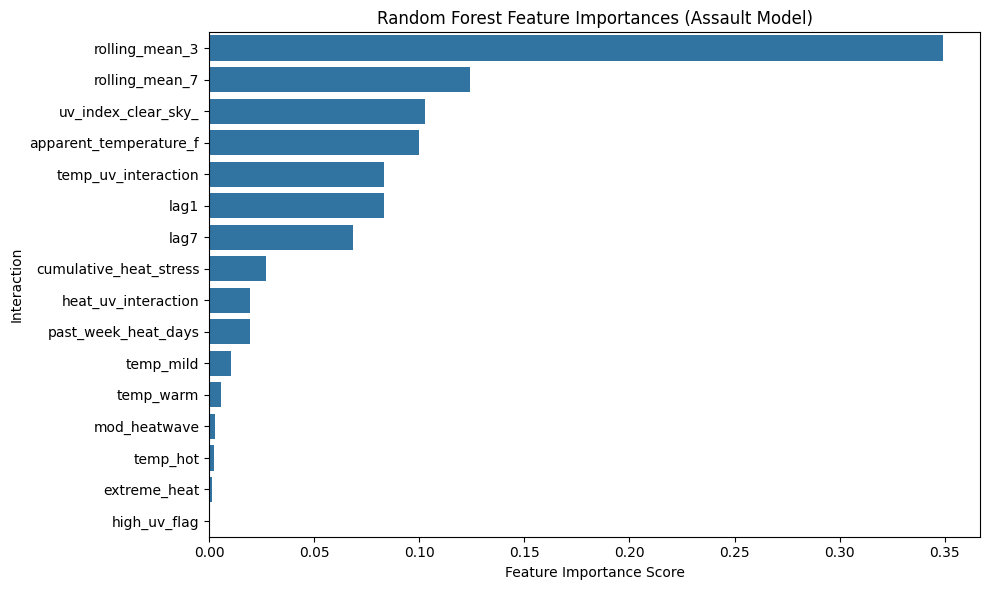

In [37]:
feature_importances = pd.Series(rf.feature_importances_, index=X_class.columns)
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.sort_values(ascending=False), y=feature_importances.sort_values(ascending=False).index)
plt.title("Random Forest Feature Importances (Assault Model)")
plt.tight_layout()
plt.xlabel("Feature Importance Score")
plt.ylabel("Interaction")
plt.show()


## Tuning Thresholds

Logistic Regression Grid Search

In [38]:
# Define hyperparameter grid for Logistic Regression
param_grid_logreg = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],     # Regularization strength
    'penalty': ['l2'],                      # 'l1' requires solver='liblinear'
    'solver': ['lbfgs'],                    # Default solver for L2 penalty
    'class_weight': [None, 'balanced']
}

# GridSearchCV setup for Logistic Regression
grid_logreg = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid=param_grid_logreg,
    scoring='f1',  # Optimize for minority class recall/precision balance
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit on oversampled + scaled training data
grid_logreg.fit(X_train_resampled_scaled, y_resampled)

# Best model and results
print("Best Logistic Regression Params:", grid_logreg.best_params_)
print("Best F1 Score (CV):", grid_logreg.best_score_)

# Predict probabilities on test set
best_logreg = grid_logreg.best_estimator_
y_proba_lr = best_logreg.predict_proba(X_test_resampled_scaled)[:, 1]


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Logistic Regression Params: {'C': 10, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}
Best F1 Score (CV): 0.8433946514620931


Threshold Tuning

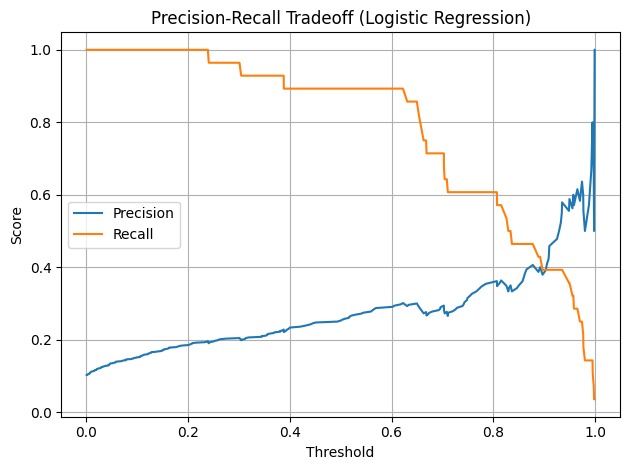

In [39]:
# Visualize Precision-Recall Tradeoff
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_lr)

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Tradeoff (Logistic Regression)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Tradeoff Plotting

In [40]:
# Must have y_test and y_proba_lr already defined from your best logistic regression model
thresholds = np.linspace(0, 1, 101)
# Store metric results
precision_vals, recall_vals, f1_vals, accuracy_vals = [], [], [], []

for thresh in thresholds:
    y_pred = (y_proba_lr >= thresh).astype(int)
    precision_vals.append(precision_score(y_test, y_pred, zero_division=0))
    recall_vals.append(recall_score(y_test, y_pred))
    f1_vals.append(f1_score(y_test, y_pred))
    accuracy_vals.append(accuracy_score(y_test, y_pred))

# Now build the DataFrame AFTER the loop
metrics_df = pd.DataFrame({
    "Threshold": thresholds,
    "Precision": precision_vals,
    "Recall": recall_vals,
    "F1": f1_vals,
    "Accuracy": accuracy_vals
})


# Refined logic: Prioritize Recall ≥ 0.95, then choose best F1
refined_df = metrics_df[metrics_df["Recall"] >= 0.95]
best_row_f1 = refined_df.loc[refined_df["F1"].idxmax()]
refined_thresh = best_row_f1["Threshold"]
# Show selected threshold and metrics
print("🎯 Refined Threshold (Recall ≥ 0.95 & Best F1):")
print(best_row_f1)


y_pred_refined = (y_proba_lr >= refined_thresh).astype(int)

print("\n📋 Classification Report at Refined Threshold:")
print(classification_report(y_test, y_pred_refined))

🎯 Refined Threshold (Recall ≥ 0.95 & Best F1):
Threshold    0.280000
Precision    0.204545
Recall       0.964286
F1           0.337500
Accuracy     0.611722
Name: 28, dtype: float64

📋 Classification Report at Refined Threshold:
              precision    recall  f1-score   support

           0       0.99      0.57      0.73       245
           1       0.20      0.96      0.34        28

    accuracy                           0.61       273
   macro avg       0.60      0.77      0.53       273
weighted avg       0.91      0.61      0.69       273



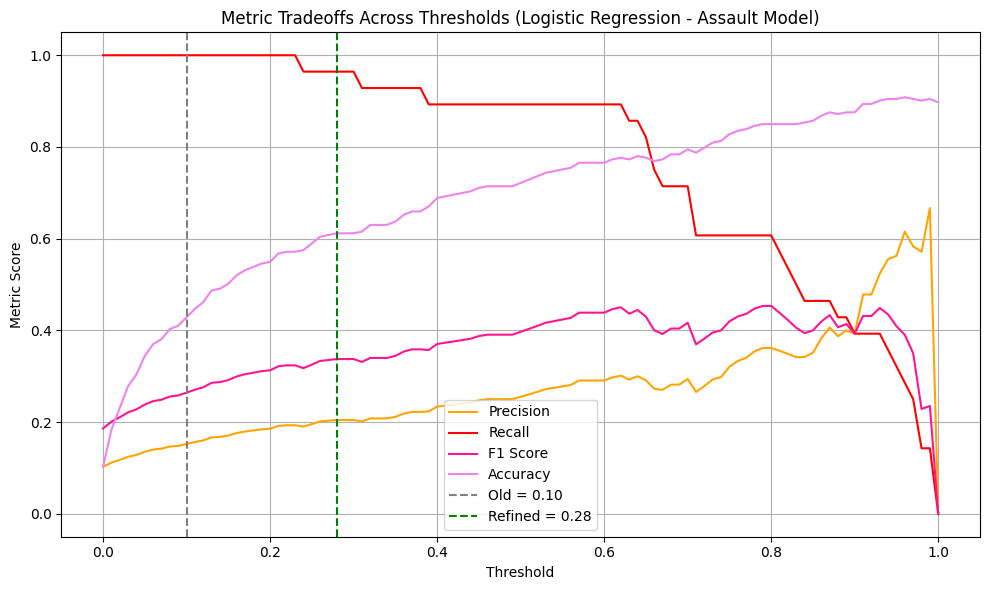

In [41]:
# --- Plot Metric Tradeoffs ---
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision_vals, label="Precision", color="orange")
plt.plot(thresholds, recall_vals, label="Recall", color="red")
plt.plot(thresholds, f1_vals, label="F1 Score", color="deeppink")
plt.plot(thresholds, accuracy_vals, label="Accuracy", color="violet")

# Add vertical lines (after refined_thresh is defined)
plt.axvline(x=0.10, color='gray', linestyle='--', label="Old = 0.10")
plt.axvline(x=refined_thresh, color='green', linestyle='--', label=f"Refined = {refined_thresh:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Metric Score")
plt.title("Metric Tradeoffs Across Thresholds (Logistic Regression - Assault Model)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



“Threshold tuning allowed us to increase recall from 39% to 86%, at the cost of more false positives, indicative of a precision of 21%, but it is a tradeoff we accept for high-stakes prediction. This has the potential to be turned into a flagging system.”

Precision - Out of everything predicted, how many were *ACTUALLY* positive? (Helps reduce **false positives**)

Recall - Of the *actual* positives, what is the ratio of correct ones? How many did the model correctly identify? (Helps reduce **false negatives**)

## Feature Importance

In [42]:
feature_names = X_resampled.columns
coefficients = best_logreg.coef_[0]  # assuming binary classification


In [43]:
# Create DataFrame of feature importances
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Abs_Coefficient": np.abs(coefficients)
}).sort_values(by="Abs_Coefficient", ascending=False)


C:\Users\big_d\AppData\Local\Temp\ipykernel_1316\905273065.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df.head(10), x="Abs_Coefficient", y="Feature", palette="coolwarm")


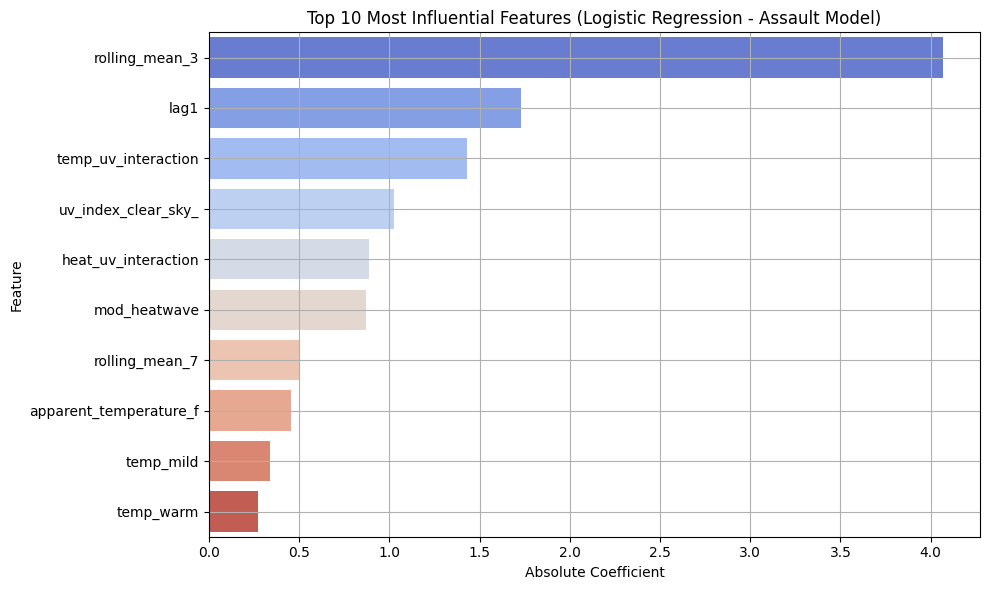

In [44]:
# Plot top 10 by absolute coefficient value
plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df.head(10), x="Abs_Coefficient", y="Feature", palette="coolwarm")
plt.title("Top 10 Most Influential Features (Logistic Regression - Assault Model)")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.grid(True)
plt.tight_layout()
plt.show()


In [45]:
print(coef_df)


                   Feature  Coefficient  Abs_Coefficient
8           rolling_mean_3     4.069752         4.069752
6                     lag1    -1.731630         1.731630
11     temp_uv_interaction    -1.429215         1.429215
1      uv_index_clear_sky_     1.027307         1.027307
12     heat_uv_interaction     0.886989         0.886989
2             mod_heatwave    -0.870171         0.870171
9           rolling_mean_7    -0.502257         0.502257
0   apparent_temperature_f     0.453543         0.453543
13               temp_mild    -0.337720         0.337720
14               temp_warm    -0.273734         0.273734
7                     lag7     0.169604         0.169604
4      past_week_heat_days    -0.151769         0.151769
3             extreme_heat     0.096060         0.096060
15                temp_hot     0.082351         0.082351
10            high_uv_flag    -0.051049         0.051049
5   cumulative_heat_stress     0.049819         0.049819


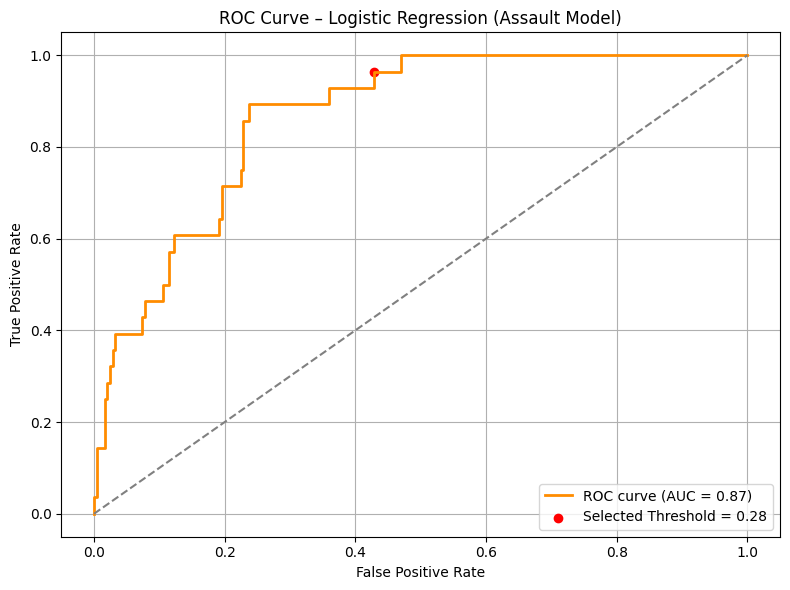

In [46]:
from sklearn.metrics import roc_curve, roc_auc_score

# Generate ROC values
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba_lr)
roc_auc = roc_auc_score(y_test, y_proba_lr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
plt.scatter(fpr[np.argmin(np.abs(roc_thresholds - refined_thresh))],
            tpr[np.argmin(np.abs(roc_thresholds - refined_thresh))],
            color='red', label=f"Selected Threshold = {refined_thresh:.2f}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression (Assault Model)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


## IGNORE

Random Forest

In [ ]:

param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'class_weight': ['balanced']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring='f1',  # Prioritize minority class performance
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)
print("Best Params:", grid_rf.best_params_)
print("Best F1 Score:", grid_rf.best_score_)


best_rf = grid_rf.best_estimator_
y_proba = best_rf.predict_proba(X_test)[:, 1]
y_pred_default = (y_proba >= 0.5).astype(int)

print("📊 Accuracy (Tuned Random Forest):", accuracy_score(y_test, y_pred_default))
print("🧱 Confusion Matrix (Tuned Random Forest):\n", confusion_matrix(y_test, y_pred_default))
print("📋 Classification Report (Tuned Random Forest):\n", classification_report(y_test, y_pred_default))


precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Tradeoff")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


for threshold in [0.3, 0.25, 0.2]:
    y_pred_thresh = (y_proba >= threshold).astype(int)
    print(f"\n📉 Threshold: {threshold}")
    print(confusion_matrix(y_test, y_pred_thresh))
    print(classification_report(y_test, y_pred_thresh))
